
-----------------------
repeat=1:
iter=1000 t_per_iter=0.0009206s 1.1e+03 iter/s 2.9e+11 bytes/s
FLOPS: 0.15 TF/s
Mem B/W: 291.60 GB/s

-----------------------
repeat=1:
iter=1000 t_per_iter=0.0009108s 1.1e+03 iter/s 2.9e+11 bytes/s
FLOPS: 0.15 TF/s
Mem B/W: 294.71 GB/s

-----------------------
repeat=2:
iter=1000 t_per_iter=0.0009072s 1.1e+03 iter/s 3e+11 bytes/s
FLOPS: 0.30 TF/s
Mem B/W: 295.88 GB/s

-----------------------
repeat=2:
iter=1000 t_per_iter=0.0009075s 1.1e+03 iter/s 3e+11 bytes/s
FLOPS: 0.30 TF/s
Mem B/W: 295.80 GB/s

-----------------------
repeat=4:
iter=1000 t_per_iter=0.0009085s 1.1e+03 iter/s 3e+11 bytes/s
FLOPS: 0.59 TF/s
Mem B/W: 295.46 GB/s

-----------------------
repeat=5:
iter=1000 t_per_iter=0.0009089s 1.1e+03 iter/s 3e+11 bytes/s
FLOPS: 0.74 TF/s
Mem B/W: 295.33 GB/s

-----------------------
repeat=7:
iter=1000 t_per_iter=0.000907s 1.1e+03 iter/s 3e+11 bytes/s
FLOPS: 1.04 TF/s
Mem B/W: 295.96 GB/s

-----------------------
repeat=11:
iter=1000 t_per_iter=0.

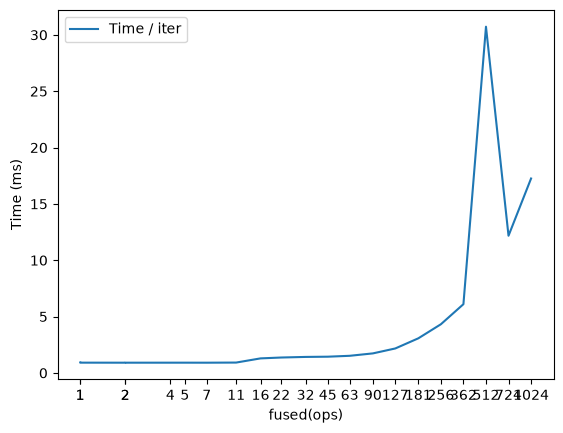

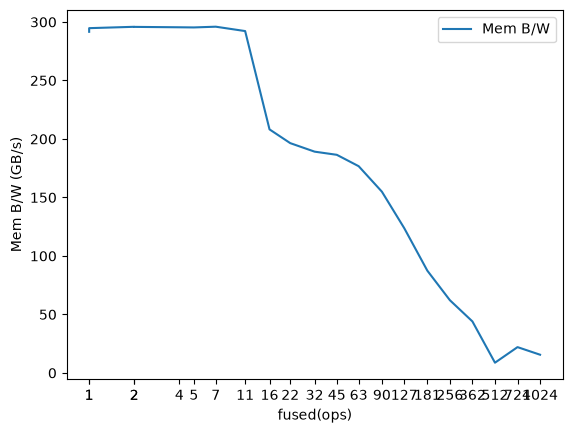

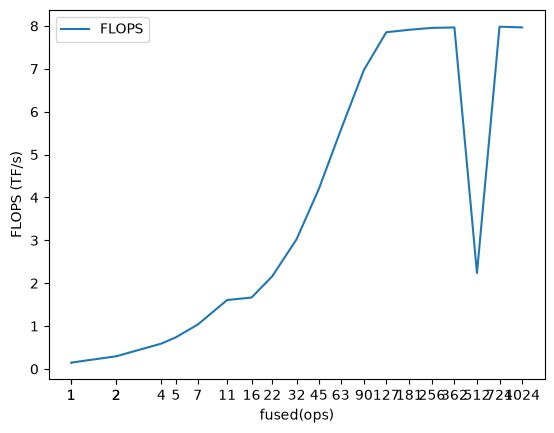

In [44]:
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullFormatter
import time

#DEVICE = "cuda"
DEVICE = "mps"

def do_test(iterations, func, data):
    torch.mps.synchronize()
    start = time.time()
    for _ in range(iterations):
        func(data)
    torch.mps.synchronize()
    end = time.time()
    return end - start


def get_f(x, repeat):
    mul_val = torch.tensor(2.0, dtype=torch.float16, device=x.device)
    add_val = torch.tensor(7.0, dtype=torch.float16, device=x.device)
    def f(x):
        for _ in range(repeat):
            #x = x * 2 + 7
            x = torch.addcmul(add_val, x, mul_val, value=1.0)
        return x
    return f

'''
def get_f(x, repeat):
    # Ensure repeat is divisible by our unroll factor (e.g., 4)
    # We will use 4 independent variables to break instruction latency
    unroll_factor = 4
    inner_loop = repeat // unroll_factor
    
    def f(x):
        # Create 4 independent registers initialized with x
        x1 = x
        x2 = x + 0.1  # slightly different to prevent compiler optimization collapses
        x3 = x + 0.2
        x4 = x + 0.3
        
        for _ in range(inner_loop):
            # The compiler can now issue these 4 instructions in parallel 
            # because none of them rely on the immediate previous line's output
            x1 = x1 * 2.0 + 7.0
            x2 = x2 * 2.0 + 7.0
            x3 = x3 * 2.0 + 7.0
            x4 = x4 * 2.0 + 7.0
            
        # Combine the results at the very end
        return (x1 + x2 + x3 + x4) / 4.0
    return f    
'''
X = torch.randn((int(2**26),), device=DEVICE, dtype=torch.float16, requires_grad=False)

repeats = []
times = []

mem_bend = []
flops_stats = []

def get_log_splits(start, end, n):
    return [int(start * (end/start)**(i/n)) for i in range(n+1)]

xes = get_log_splits(1, 1024, 20)

for n in xes:
    print(f"\n-----------------------\nrepeat={n}:")
    f = get_f(X, n)
    #f = torch.jit.trace(f,X)
    torch._dynamo.reset()
    f = torch.compile(f)
    for _ in range(5): f(X)
    #torch.mps.synchronize()
    #print(torch.jit.last_executed_optimized_graph())
   
    M = 1000

    data_size = X.numel() * X.element_size()
    t_iter = do_test(M, f, X)/M # time per iteration
    iter_per_sec = 1 / t_iter  # iterations per second
    memory_per_second = iter_per_sec * data_size * 2
    flops = 2 * n * X.numel() * iter_per_sec

    print(f"iter={M} t_per_iter={t_iter:.4}s {iter_per_sec:.2} iter/s {memory_per_second:.2} bytes/s")

    print(f"FLOPS: { flops/1e12:.2f} TF/s")
    print(f"Mem B/W: {memory_per_second/1e9:.2f} GB/s")
    
    repeats.append(n)
    times.append(t_iter*1000)
    mem_bend.append(memory_per_second/1e9)
    flops_stats.append(flops/1e12)

plt.plot(repeats, times, label="Time / iter")
plt.xlabel("fused(ops)")
plt.ylabel("Time (ms)") 
plt.legend()
plt.xscale("log", base=2)
ax = plt.gca()
ax.set_xticks(repeats)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.ticklabel_format(axis="y", style="plain")
plt.show()

plt.plot(repeats, mem_bend, label="Mem B/W")
plt.xlabel("fused(ops)")
plt.ylabel("Mem B/W (GB/s)") 
plt.legend()
plt.xscale("log", base=2)
ax = plt.gca()
ax.set_xticks(repeats)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.ticklabel_format(axis="y", style="plain")
plt.show()

plt.plot(repeats, flops_stats, label="FLOPS")
plt.xlabel("fused(ops)")
plt.ylabel("FLOPS (TF/s)") 
plt.legend()
plt.xscale("log", base=2)
ax = plt.gca()
ax.set_xticks(repeats)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.ticklabel_format(axis="y", style="plain")
plt.show()



#print(torch.compile(get_f(X, 10)))






So from what I see, I have on my RTX 3060 peaks:
  - Mem B at around 320 GB/s
  - Compute at ~6 TFLOPS